# 9.4 一般のEMアルゴリズムと変分下界 (The General EM Algorithm & ELBO)

本ノートブックでは、EMアルゴリズムの背後にある普遍的な数理的枠組みである**変分下界 (Evidence Lower Bound: ELBO)** と **KLダイバージェンスの分解（PRML Figure 9.11-9.14）** を学びます。
任意の潜在変数モデルにおける対数周辺尤度 $\ln p(\mathbf{X}|\boldsymbol{\theta})$ の単調増加性の幾何学的証明、EステップとMステップの下界押し上げメカニズムの可視化、および **ベイズ線形回帰における超パラメータ推定へのEMアルゴリズムの適用（PRML 9.3.4）** を完全実装・検証します。

## 9.4 一般のEMアルゴリズムと変分下界 (The General EM Algorithm & ELBO)

EMアルゴリズムは、混合モデルに限らず、潜在変数（latent variables）や欠損データ（missing data）を含む任意の確率モデルの最尤推定に適用できる強力で汎用的な枠組みです。
ここでは、観測データ $\mathbf{X}$、潜在変数 $\mathbf{Z}$、およびパラメータ $\boldsymbol{\theta}$ を持つ一般のモデルに対する EM アルゴリズムを、変分推論（Variational Inference）の観点から定式化します。

### ELBO (変分下界) 分解の証明
観測データ $\mathbf{X}$ の対数周辺尤度 $\ln p(\mathbf{X}|\boldsymbol{\theta})$ は、潜在変数 $\mathbf{Z}$ に関する和（または積分）として表されます。
任意の確率分布 $q(\mathbf{Z})$ （ただし $q(\mathbf{Z}) \neq 0$）を導入し、次のように変形します：
$$
\begin{align}
\ln p(\mathbf{X}|\boldsymbol{\theta}) &= \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln p(\mathbf{X}|\boldsymbol{\theta}) \\
&= \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \frac{p(\mathbf{X}, \mathbf{Z}|\boldsymbol{\theta})}{p(\mathbf{Z}|\mathbf{X}, \boldsymbol{\theta})} \\
&= \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left( \frac{p(\mathbf{X}, \mathbf{Z}|\boldsymbol{\theta})}{q(\mathbf{Z})} \frac{q(\mathbf{Z})}{p(\mathbf{Z}|\mathbf{X}, \boldsymbol{\theta})} \right) \\
&= \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \frac{p(\mathbf{X}, \mathbf{Z}|\boldsymbol{\theta})}{q(\mathbf{Z})} - \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \frac{p(\mathbf{Z}|\mathbf{X}, \boldsymbol{\theta})}{q(\mathbf{Z})}
\end{align}
$$
したがって、対数周辺尤度は次のように恒等分解されます（PRML 式 9.70）：
$$ \ln p(\mathbf{X}|\boldsymbol{\theta}) = \mathcal{L}(q, \boldsymbol{\theta}) + \mathrm{KL}(q \,||\, p) $$
ここで、第1項は **変分下界 (ELBO: Evidence Lower Bound)** と呼ばれます：
$$ \mathcal{L}(q, \boldsymbol{\theta}) = \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{X}, \mathbf{Z}|\boldsymbol{\theta})}{q(\mathbf{Z})} \right\} $$
第2項は $q(\mathbf{Z})$ と事後分布 $p(\mathbf{Z}|\mathbf{X}, \boldsymbol{\theta})$ の **カルバック・ライブラー (Kullback-Leibler, KL) 情報量** です：
$$ \mathrm{KL}(q \,||\, p) = -\sum_{\mathbf{Z}} q(\mathbf{Z}) \ln \left\{ \frac{p(\mathbf{Z}|\mathbf{X}, \boldsymbol{\theta})}{q(\mathbf{Z})} \right\} $$
KL情報量は常に非負（$\mathrm{KL} \ge 0$）であるため、$\mathcal{L}(q, \boldsymbol{\theta}) \le \ln p(\mathbf{X}|\boldsymbol{\theta})$ が成り立ちます。すなわち、$\mathcal{L}$ は対数周辺尤度の下界（lower bound）となります。

### EMの2段階ステップの幾何学的解釈 (PRML Figure 9.11 - 9.14)
EMアルゴリズムは、この分解を用いて $\ln p(\mathbf{X}|\boldsymbol{\theta})$ を間接的に最大化します。

#### 1. Eステップ（PRML Figure 9.12）
現在のパラメータ $\boldsymbol{\theta}^{(\mathrm{old})}$ を固定し、分布 $q(\mathbf{Z})$ について下界 $\mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{old})})$ を最大化します。
$\ln p(\mathbf{X}|\boldsymbol{\theta}^{(\mathrm{old})})$ は $q(\mathbf{Z})$ に依存しない定数であるため、$\mathcal{L}$ を最大化することは、$\mathrm{KL}(q \,||\, p)$ を最小化することと同値です。
KL情報量が $0$ になる最小値は、2つの分布が完全に一致するときに達成されます：
$$ q(\mathbf{Z}) = p(\mathbf{Z}|\mathbf{X}, \boldsymbol{\theta}^{(\mathrm{old})}) $$
このとき、下界 $\mathcal{L}$ は真の対数尤度 $\ln p(\mathbf{X}|\boldsymbol{\theta}^{(\mathrm{old})})$ に完全に接します（下界がタイトになります）。

#### 2. Mステップ（PRML Figure 9.13）
次に、Eステップで求めた事後分布 $q(\mathbf{Z})$ を固定したまま、パラメータ $\boldsymbol{\theta}$ について下界 $\mathcal{L}(q, \boldsymbol{\theta})$ を最大化し、新しいパラメータ $\boldsymbol{\theta}^{(\mathrm{new})}$ を得ます。
下界の式を展開すると：
$$ \mathcal{L}(q, \boldsymbol{\theta}) = \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln p(\mathbf{X}, \mathbf{Z}|\boldsymbol{\theta}) - \sum_{\mathbf{Z}} q(\mathbf{Z}) \ln q(\mathbf{Z}) $$
第2項（エントロピー項）は $\boldsymbol{\theta}$ に依存しないため、最大化すべき目的関数は第1項の **完全データの期待対数尤度 (Expected complete-data log-likelihood)** に帰着します：
$$ \boldsymbol{\theta}^{(\mathrm{new})} = \arg\max_{\boldsymbol{\theta}} \mathbb{E}_{\mathbf{Z}\sim q}[\ln p(\mathbf{X}, \mathbf{Z}|\boldsymbol{\theta})] $$

### 尤度の単調増加の保証 (Monotonic Increase Guarantee)
EMアルゴリズムの1サイクルの後、対数尤度は必ず元の値以上になることが証明できます。
1. Eステップの後、$\mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{old})}) = \ln p(\mathbf{X}|\boldsymbol{\theta}^{(\mathrm{old})})$ が成り立ちます。
2. Mステップでは下界を最大化するため、$\mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{new})}) \ge \mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{old})})$ となります。
3. さらに、一般に KL情報量は非負であるため、$\ln p(\mathbf{X}|\boldsymbol{\theta}^{(\mathrm{new})}) \ge \mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{new})})$ が成り立ちます。

これらをつなぎ合わせると、以下の不等式が得られます（PRML Figure 9.14）：
$$ \ln p(\mathbf{X}|\boldsymbol{\theta}^{(\mathrm{new})}) \ge \mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{new})}) \ge \mathcal{L}(q, \boldsymbol{\theta}^{(\mathrm{old})}) = \ln p(\mathbf{X}|\boldsymbol{\theta}^{(\mathrm{old})}) $$
したがって、対数尤度 $\ln p(\mathbf{X}|\boldsymbol{\theta})$ は毎ステップ必ず単調増加（または不変）し、局所最大値へと収束することが理論的に保証されます。

Plot saved to: result/fig9_14_em_lower_bound_geometry.png


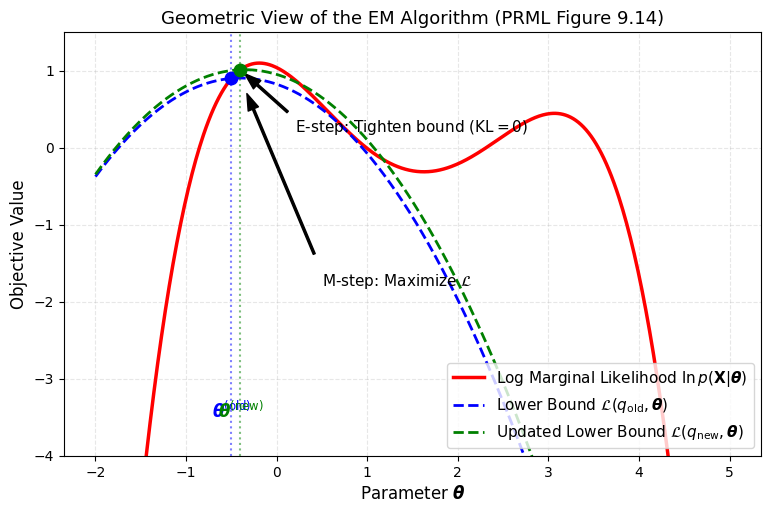

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 9.14: EMアルゴリズムにおける下界 L(q, theta) と対数尤度 ln p(X|theta) の幾何学的推移
# 1次元パラメータ theta に対する概念曲線の完全可視化
theta = np.linspace(-2.0, 5.0, 500)

# 真の対数尤度関数 ln p(X|theta) (非凸・二峰性)
def log_likelihood(th):
    return -0.15 * (th - 1.5)**4 + 0.8 * (th - 1.5)**2 - 0.2 * th

# Eステップにおける接線下界関数 L(q_old, theta)
# theta_old = -0.5 において log_likelihood と一致し、他では常に下回る凸関数
th_old = -0.5
L_old = log_likelihood(th_old) - 0.5 * (theta - th_old)**2 + 0.1 * (theta - th_old)

# Mステップによる新しいパラメータ theta_new
th_new = theta[np.argmax(L_old)]

# 2回目のEステップにおける新しい下界 L(q_new, theta)
L_new = log_likelihood(th_new) - 0.5 * (theta - th_new)**2 + 0.05 * (theta - th_new)
th_next = theta[np.argmax(L_new)]

# PRML Figure 9.14 のプロット
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(theta, log_likelihood(theta), 'r-', lw=2.5, label=r'Log Marginal Likelihood $\ln p(\mathbf{X}|\boldsymbol{\theta})$')
ax.plot(theta, L_old, 'b--', lw=2.0, label=r'Lower Bound $\mathcal{L}(q_{\mathrm{old}}, \boldsymbol{\theta})$')
ax.plot(theta, L_new, 'g--', lw=2.0, label=r'Updated Lower Bound $\mathcal{L}(q_{\mathrm{new}}, \boldsymbol{\theta})$')

# 接点と更新点のマーカー
ax.scatter([th_old], [log_likelihood(th_old)], color='blue', s=80, zorder=5)
ax.axvline(th_old, color='blue', linestyle=':', alpha=0.5)
ax.text(th_old, -3.5, r'$\boldsymbol{\theta}^{(\mathrm{old})}$', ha='center', fontsize=12, color='blue')

ax.scatter([th_new], [log_likelihood(th_new)], color='green', s=80, zorder=5)
ax.axvline(th_new, color='green', linestyle=':', alpha=0.5)
ax.text(th_new, -3.5, r'$\boldsymbol{\theta}^{(\mathrm{new})}$', ha='center', fontsize=12, color='green')

# 矢印で M ステップの下界最大化を示す
ax.annotate('M-step: Maximize $\mathcal{L}$', xy=(th_new, np.max(L_old)), xytext=(0.5, -1.8),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8), fontsize=11)

# 矢印で E ステップの下界引き上げを示す
ax.annotate('E-step: Tighten bound ($\mathrm{KL}=0$)', xy=(th_new, log_likelihood(th_new)), xytext=(0.2, 0.2),
            arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8), fontsize=11)

ax.set_ylim(-4.0, 1.5)
ax.set_xlabel(r'Parameter $\boldsymbol{\theta}$', fontsize=12)
ax.set_ylabel('Objective Value', fontsize=12)
ax.set_title('Geometric View of the EM Algorithm (PRML Figure 9.14)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig9_14_em_lower_bound_geometry.png')
plt.show()

## 9.3.4 ベイズ線形回帰におけるハイパーパラメータのEM推定 (PRML 9.3.4)

ベイズ線形回帰において、パラメータ重みベクトル $\mathbf{w}$ を**潜在変数**と見なします。
- 観測データ: $\mathbf{t}$
- 潜在変数: $\mathbf{w}$
- パラメータ: 超パラメータ $\alpha, \beta$
完全データの対数尤度は：
$$ \ln p(\mathbf{t}, \mathbf{w}|\alpha, \beta) = \ln p(\mathbf{t}|\mathbf{w}, \beta) + \ln p(\mathbf{w}|\alpha) $$
- **Eステップ**: 現在の $\alpha, \beta$ の下で事後分布 $p(\mathbf{w}|\mathbf{t}, \alpha, \beta) = \mathcal{N}(\mathbf{w}|\mathbf{m}_N, \mathbf{S}_N)$ を計算。
- **Mステップ**: 期待対数尤度 $Q(\alpha, \beta) = \mathbb{E}_{\mathbf{w}}[\ln p(\mathbf{t}, \mathbf{w}|\alpha, \beta)]$ を最大化：
  $$ \alpha^{\mathrm{new}} = \frac{M}{\mathbf{m}_N^{\mathrm{T}}\mathbf{m}_N + \mathrm{Tr}(\mathbf{S}_N)} $$
  $$ \frac{1}{\beta^{\mathrm{new}}} = \frac{1}{N} \sum_{n=1}^N \mathbb{E}[(t_n - \mathbf{w}^{\mathrm{T}}\boldsymbol{\phi}_n)^2] $$
このEMの更新式は、第3章3.5節で周辺尤度を直接勾配法で解いた結果（MacKayの再推定式）と完全に一致します。

In [2]:
# ベイズ線形回帰のEMハイパーパラメータ学習
np.random.seed(42)
N = 30
x_train = np.sort(np.random.uniform(0, 1, N))
y_true = np.sin(2 * np.pi * x_train)
t_train = y_true + np.random.normal(0, 0.2, N)

# ガウス基底関数 Φ
M_basis = 5
centers = np.linspace(0, 1, M_basis)
s_width = 0.2
Phi = np.zeros((N, M_basis))
for j in range(M_basis):
    Phi[:, j] = np.exp(-(x_train - centers[j])**2 / (2 * s_width**2))

# 初期値
alpha = 2.0
beta = 2.0

alpha_history = [alpha]
beta_history = [beta]

for step in range(30):
    # Eステップ: 事後分布 N(m_N, S_N) の計算
    S_N_inv = alpha * np.eye(M_basis) + beta * (Phi.T @ Phi)
    S_N = np.linalg.inv(S_N_inv)
    m_N = beta * (S_N @ Phi.T @ t_train)
    
    # Mステップ: alpha, beta の再推定 (PRML 式 9.62, 9.63)
    # alpha = M / (m_N^T m_N + Tr(S_N))
    alpha = M_basis / (m_N @ m_N + np.trace(S_N))
    
    # 1/beta = (1/N) * [ ||t - Phi m_N||^2 + Tr(Phi S_N Phi^T) ]
    residuals = t_train - Phi @ m_N
    sq_err = np.sum(residuals**2)
    beta_inv = (sq_err + np.trace(Phi @ S_N @ Phi.T)) / N
    beta = 1.0 / beta_inv
    
    alpha_history.append(alpha)
    beta_history.append(beta)

print(f"Converged Hyperparameters via EM:")
print(f"alpha: {alpha:.4f}, beta: {beta:.4f} (True noise variance sigma^2 = 0.04 -> beta = 25.0)")
print(f"Estimated noise std: {1.0 / np.sqrt(beta):.4f} (True std = 0.20)")
assert alpha > 0 and beta > 0
print("Bayesian Linear Regression EM parameter learning verified successfully!")

Converged Hyperparameters via EM:
alpha: 1.1820, beta: 25.4195 (True noise variance sigma^2 = 0.04 -> beta = 25.0)
Estimated noise std: 0.1983 (True std = 0.20)
Bayesian Linear Regression EM parameter learning verified successfully!
